<a href="https://colab.research.google.com/github/Wasayyyyyy/CV-Tasks/blob/main/LAB_05_HOG_Skin_Lesion_043.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 05 (combined): HOG-Based Skin Lesion Detection and Classification
**Pipeline:** Image → Preprocessing (resize, grayscale, CLAHE, optional spatial filter) → HOG → ML classifier → Benign / Suspicious decision

This notebook applies the lab's HOG pipeline to **dermoscopic skin lesion images** and borrows from the ISIC-2019 paper: RBF-SVM as the classifier, the five spatial filters (average, Gaussian, median, sharpening, Sobel), and an efficiency-aware comparison (feature size and timing).

**Data:** DermaMNIST (HAM10000 dermoscopy images, part of the ISIC archive), 7 classes, official train/val/test split. It downloads automatically with `pip`: no Kaggle account, API key or manual download.

## 1. Setup

In [1]:
!pip -q install medmnist scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.3 MB/s eta 0:00:00


In [2]:
import os, time, random, warnings
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt, seaborn as sns
from skimage.feature import hog
from joblib import Parallel, delayed
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report)
warnings.filterwarnings("ignore")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)

# ---------------- CONFIG ----------------
SEED = 42
IMG_SIZE = 64                      # common resolution (DermaMNIST is provided at 64x64)
CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]   # label ids 0..6
FULL_NAMES = {"akiec": "actinic keratosis / intraepithelial carcinoma", "bcc": "basal cell carcinoma",
              "bkl": "benign keratosis-like lesion", "df": "dermatofibroma", "mel": "melanoma",
              "nv": "melanocytic nevus", "vasc": "vascular lesion"}
SUSPICIOUS = ["akiec", "bcc", "mel"]            # Class 1 in the binary task
CELL_SIZES = [4, 8, 16]
ORIENTATIONS = [6, 9, 12]
REFER_THRESHOLD = 0.40             # refer for review if P(suspicious) >= this (low value favours recall)
# ----------------------------------------
random.seed(SEED); np.random.seed(SEED)
os.makedirs("results", exist_ok=True)

def box(title, body, width=78):
    lines = str(body).split("\n")
    w = max(width, max(len(l) for l in lines) + 4, len(title) + 6)
    print("+" + "=" * (w - 2) + "+")
    print("| " + title.center(w - 4) + " |")
    print("+" + "-" * (w - 2) + "+")
    for l in lines:
        print("| " + l.ljust(w - 4) + " |")
    print("+" + "=" * (w - 2) + "+\n")

## 2. Load and inspect the dataset

100%|██████████| 100M/100M [01:12<00:00, 1.37MB/s] 


+=============================================================================================+
|                           DATASET SUMMARY (DermaMNIST / HAM10000)                           |
+---------------------------------------------------------------------------------------------+
| Image shape  : (64, 64, 3) (RGB, uint8)                                                     |
| Train/Val/Test: 7007 / 1003 / 2005                                                          |
| Suspicious share (train): 19.5%   (classes are imbalanced -> macro-F1 + class weights used) |
|                                                                                             |
|        train  val  test binary_class                                                        |
| akiec    228   33    66   Suspicious                                                        |
| bcc      359   52   103   Suspicious                                                        |
| bkl      769  110   220       Benign  

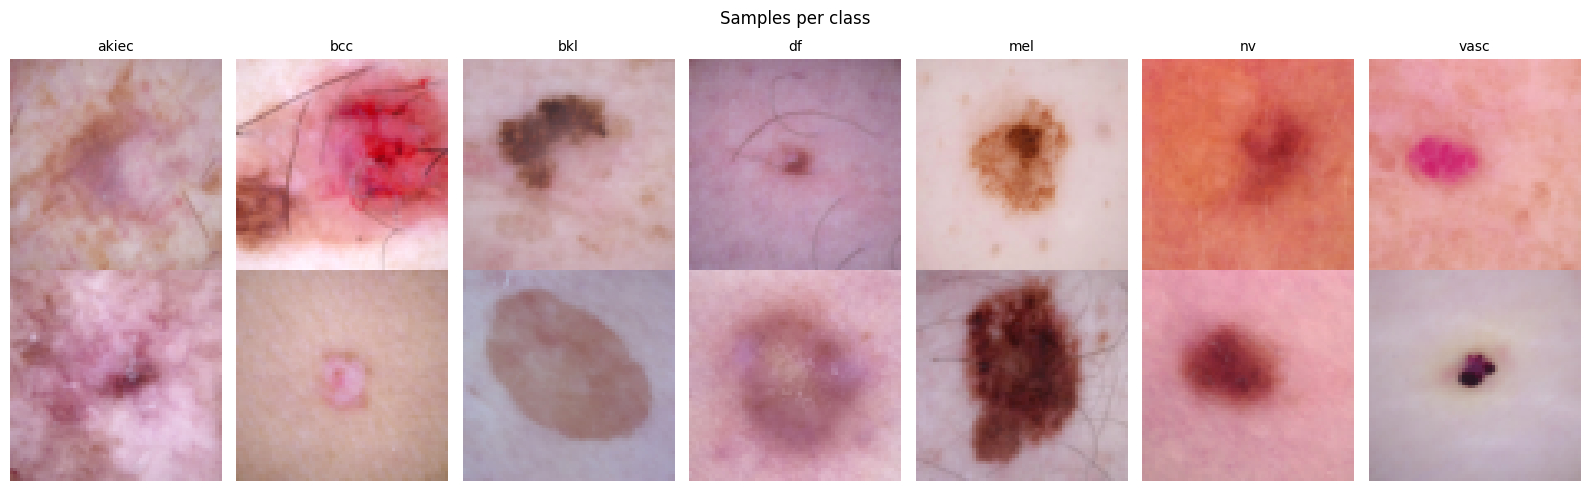

In [3]:
from medmnist import DermaMNIST
def load(split):
    d = DermaMNIST(split=split, download=True, size=IMG_SIZE)
    return d.imgs, d.labels.ravel().astype(int)
rgb_tr, ym_tr = load("train"); rgb_va, ym_va = load("val"); rgb_te, ym_te = load("test")
sus_ids = [CLASSES.index(c) for c in SUSPICIOUS]
yb_tr, yb_va, yb_te = [np.isin(y, sus_ids).astype(int) for y in (ym_tr, ym_va, ym_te)]

cnt = pd.DataFrame({"train": np.bincount(ym_tr, minlength=7), "val": np.bincount(ym_va, minlength=7),
                    "test": np.bincount(ym_te, minlength=7)}, index=CLASSES)
cnt["binary_class"] = ["Suspicious" if c in SUSPICIOUS else "Benign" for c in CLASSES]
box("DATASET SUMMARY (DermaMNIST / HAM10000)",
    f"Image shape  : {rgb_tr.shape[1:]} (RGB, uint8)\nTrain/Val/Test: {len(ym_tr)} / {len(ym_va)} / {len(ym_te)}\n"
    f"Suspicious share (train): {yb_tr.mean()*100:.1f}%   (classes are imbalanced -> macro-F1 + class weights used)\n\n"
    + cnt.to_string())

fig, ax = plt.subplots(2, 7, figsize=(16, 5))
for k, c in enumerate(CLASSES):
    for r in range(2):
        i = np.where(ym_tr == k)[0][r]
        ax[r, k].imshow(rgb_tr[i]); ax[r, k].axis("off")
        if r == 0: ax[r, k].set_title(c, fontsize=10)
plt.suptitle("Samples per class"); plt.tight_layout(); plt.show()

## 3. Preprocessing (resize → grayscale → optional spatial filter → CLAHE) and HOG

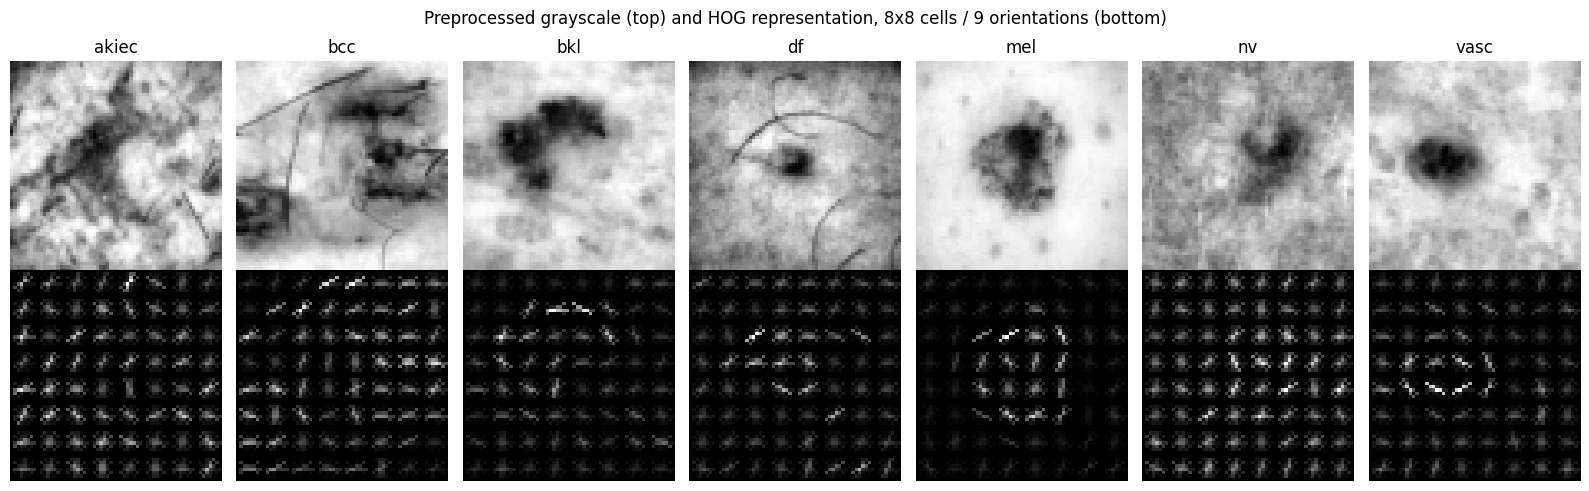

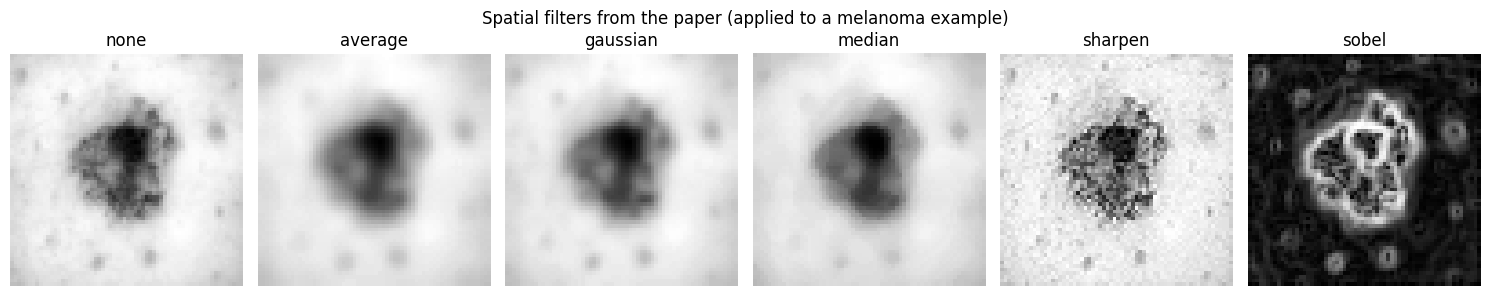

+=============================================================================+
|                          HOG FEATURE DIMENSIONALITY                         |
+-----------------------------------------------------------------------------+
| Image 64x64, cell 8x8, 9 orientations, block 2x2 -> 1764 features per image |
+=============================================================================+



In [4]:
gray_tr = [cv2.cvtColor(i, cv2.COLOR_RGB2GRAY) for i in rgb_tr]
gray_va = [cv2.cvtColor(i, cv2.COLOR_RGB2GRAY) for i in rgb_va]
gray_te = [cv2.cvtColor(i, cv2.COLOR_RGB2GRAY) for i in rgb_te]

def sobel(img):
    gx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3); gy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
    m = np.sqrt(gx ** 2 + gy ** 2)
    return cv2.normalize(m, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
SHARP = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
FILTERS = {"none": lambda x: x, "average": lambda x: cv2.blur(x, (5, 5)),
           "gaussian": lambda x: cv2.GaussianBlur(x, (5, 5), 0), "median": lambda x: cv2.medianBlur(x, 5),
           "sharpen": lambda x: cv2.filter2D(x, -1, SHARP), "sobel": sobel}

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
def preprocess(gray, filt="none"):
    g = cv2.resize(gray, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)   # common resolution
    return clahe.apply(FILTERS[filt](g))                                       # filter, then contrast normalisation

def hog_feat(img, c, o):
    return hog(img, orientations=o, pixels_per_cell=(c, c), cells_per_block=(2, 2),
               block_norm="L2-Hys", feature_vector=True)
def extract(imgs, c, o):
    return np.asarray(Parallel(n_jobs=-1, batch_size=64)(delayed(hog_feat)(i, c, o) for i in imgs), dtype=np.float32)

pre_tr = [preprocess(i) for i in gray_tr]; pre_va = [preprocess(i) for i in gray_va]; pre_te = [preprocess(i) for i in gray_te]

# Visualise HOG for one example of each class
fig, ax = plt.subplots(2, 7, figsize=(16, 5))
for k, c in enumerate(CLASSES):
    i = np.where(ym_tr == k)[0][0]
    _, vis = hog(pre_tr[i], orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm="L2-Hys", visualize=True)
    ax[0, k].imshow(pre_tr[i], cmap="gray"); ax[0, k].set_title(c); ax[0, k].axis("off")
    ax[1, k].imshow(vis / (vis.max() + 1e-9), cmap="gray"); ax[1, k].axis("off")
plt.suptitle("Preprocessed grayscale (top) and HOG representation, 8x8 cells / 9 orientations (bottom)"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 6, figsize=(15, 3)); i = np.where(ym_tr == 4)[0][0]
for a, f in zip(ax, FILTERS):
    a.imshow(preprocess(gray_tr[i], f), cmap="gray"); a.set_title(f); a.axis("off")
plt.suptitle("Spatial filters from the paper (applied to a melanoma example)"); plt.tight_layout(); plt.show()
box("HOG FEATURE DIMENSIONALITY", f"Image {IMG_SIZE}x{IMG_SIZE}, cell 8x8, 9 orientations, block 2x2 -> {len(hog_feat(pre_tr[0], 8, 9))} features per image")

## 4. Experiment A: HOG cell size × orientations (RBF-SVM)
All 9 combinations on **binary** and **7-class** tasks. Models are trained on the train split and the best setting is chosen on the **validation** split (the test split is kept for final reporting). Takes a few minutes.

In [5]:
def bmet(y, p):
    return dict(Accuracy=accuracy_score(y, p), Precision=precision_score(y, p, zero_division=0),
                Recall=recall_score(y, p, zero_division=0), F1=f1_score(y, p, zero_division=0))
def mmet(y, p):
    return dict(Accuracy=accuracy_score(y, p), Precision=precision_score(y, p, average="macro", zero_division=0),
                Recall=recall_score(y, p, average="macro", zero_division=0), F1=f1_score(y, p, average="macro", zero_division=0))

class RBFSVM:
    """RBF-SVM using a BLAS-computed kernel matrix (much faster than SVC(kernel='rbf') on HOG vectors)."""
    def __init__(self, C=10, probability=False):
        self.C, self.prob = C, probability
    def fit(self, X, y):
        self.X = X; self.gamma = 1.0 / (X.shape[1] * X.var())
        K = rbf_kernel(X, X, gamma=self.gamma)
        self.m = SVC(kernel="precomputed", C=self.C, class_weight="balanced", probability=self.prob, random_state=SEED).fit(K, y)
        self.classes_ = self.m.classes_; return self
    def _k(self, X): return rbf_kernel(X, self.X, gamma=self.gamma)
    def predict(self, X): return self.m.predict(self._k(X))
    def predict_proba(self, X): return self.m.predict_proba(self._k(X))

rows = []
for c in CELL_SIZES:
    for o in ORIENTATIONS:
        t0 = time.time()
        Xtr, Xva = extract(pre_tr, c, o), extract(pre_va, c, o)
        g = 1.0 / (Xtr.shape[1] * Xtr.var())
        Ktr, Kva = rbf_kernel(Xtr, Xtr, gamma=g), rbf_kernel(Xva, Xtr, gamma=g)
        mb = bmet(yb_va, SVC(kernel="precomputed", C=10, class_weight="balanced").fit(Ktr, yb_tr).predict(Kva))
        mm = mmet(ym_va, SVC(kernel="precomputed", C=10, class_weight="balanced").fit(Ktr, ym_tr).predict(Kva))
        rows.append({"Cell": f"{c}x{c}", "Orient": o, "Dim": Xtr.shape[1],
                     "Bin_Acc": mb["Accuracy"], "Bin_Prec": mb["Precision"], "Bin_Rec": mb["Recall"], "Bin_F1": mb["F1"],
                     "Multi_Acc": mm["Accuracy"], "Multi_F1(macro)": mm["F1"], "Time_s": time.time() - t0})
        print(f"done cell={c} orient={o} ({time.time()-t0:.0f}s)")
        del Xtr, Xva, Ktr, Kva
grid = pd.DataFrame(rows); grid.to_csv("results/hog_parameter_grid.csv", index=False)
best = grid.sort_values(["Bin_F1", "Multi_F1(macro)"], ascending=False).iloc[0]
BEST_C, BEST_O = int(best.Cell.split("x")[0]), int(best.Orient)
box("EXPERIMENT A: HOG PARAMETERS (RBF-SVM, validation split)", grid.round(4).to_string(index=False) +
    f"\n\nBest configuration (by binary F1 on validation): cell {BEST_C}x{BEST_C}, {BEST_O} orientations")

done cell=4 orient=6 (73s)
done cell=4 orient=9 (79s)
done cell=4 orient=12 (85s)
done cell=8 orient=6 (23s)
done cell=8 orient=9 (25s)
done cell=8 orient=12 (27s)
done cell=16 orient=6 (13s)
done cell=16 orient=9 (13s)
done cell=16 orient=12 (14s)
+=============================================================================================+
|                   EXPERIMENT A: HOG PARAMETERS (RBF-SVM, validation split)                  |
+---------------------------------------------------------------------------------------------+
|  Cell  Orient   Dim  Bin_Acc  Bin_Prec  Bin_Rec  Bin_F1  Multi_Acc  Multi_F1(macro)  Time_s |
|   4x4       6  5400   0.7986    0.4375   0.1071  0.1721     0.6830           0.1835 72.6423 |
|   4x4       9  8100   0.7986    0.4318   0.0969  0.1583     0.6730           0.1581 78.7488 |
|   4x4      12 10800   0.8136    0.6000   0.1378  0.2241     0.6730           0.1458 84.7351 |
|   8x8       6  1176   0.7986    0.4643   0.1990  0.2786     0.6979           

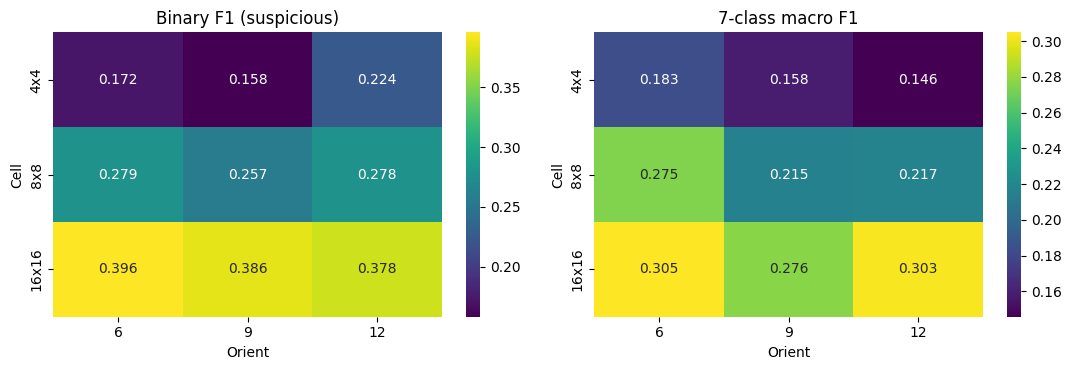

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
order = [f"{c}x{c}" for c in CELL_SIZES]
for a, col, t in zip(ax, ["Bin_F1", "Multi_F1(macro)"], ["Binary F1 (suspicious)", "7-class macro F1"]):
    sns.heatmap(grid.pivot(index="Cell", columns="Orient", values=col).loc[order], annot=True, fmt=".3f", cmap="viridis", ax=a); a.set_title(t)
plt.tight_layout(); plt.show()

## 5. Experiment B: Classifier comparison at the best HOG setting (test split)

In [7]:
Xtr, Xva, Xte = [extract(p, BEST_C, BEST_O) for p in (pre_tr, pre_va, pre_te)]
models = {
    "SVM (RBF)":     lambda: RBFSVM(C=10),
    "SVM (Linear)":  lambda: LinearSVC(C=0.5, class_weight="balanced", max_iter=3000, random_state=SEED),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=300, class_weight="balanced", n_jobs=-1, random_state=SEED),
    "kNN (k=7)":     lambda: KNeighborsClassifier(n_neighbors=7, metric="cosine", weights="distance"),
}
rows, preds = [], {}
for name, mk in models.items():
    t0 = time.time(); mb_ = mk().fit(Xtr, yb_tr); mm_ = mk().fit(Xtr, ym_tr); t_fit = time.time() - t0
    t0 = time.time(); pb, pm = mb_.predict(Xte), mm_.predict(Xte); t_inf = (time.time() - t0) / 2 / len(Xte) * 1000
    preds[name] = (pb, pm); b, m = bmet(yb_te, pb), mmet(ym_te, pm)
    rows.append({"Classifier": name, "Bin_Acc": b["Accuracy"], "Bin_Prec": b["Precision"], "Bin_Rec": b["Recall"], "Bin_F1": b["F1"],
                 "Multi_Acc": m["Accuracy"], "Multi_Prec": m["Precision"], "Multi_Rec": m["Recall"], "Multi_F1": m["F1"],
                 "Train_s": t_fit, "Infer_ms/img": t_inf})
cmp_df = pd.DataFrame(rows); cmp_df.to_csv("results/classifier_comparison.csv", index=False)
box(f"EXPERIMENT B: CLASSIFIER COMPARISON (HOG cell {BEST_C}x{BEST_C}, {BEST_O} orient., test split)",
    cmp_df.round(4).to_string(index=False) + f"\n\nFeature dimension: {Xtr.shape[1]}\nBin_* = suspicious class (positive); Multi_* = macro average over 7 classes")

+======================================================================================================================+
|                     EXPERIMENT B: CLASSIFIER COMPARISON (HOG cell 16x16, 6 orient., test split)                      |
+----------------------------------------------------------------------------------------------------------------------+
|    Classifier  Bin_Acc  Bin_Prec  Bin_Rec  Bin_F1  Multi_Acc  Multi_Prec  Multi_Rec  Multi_F1  Train_s  Infer_ms/img |
|     SVM (RBF)   0.7736    0.4184   0.4056  0.4119     0.6284      0.4051     0.2782    0.2767   7.2925        0.2768 |
|  SVM (Linear)   0.6294    0.3017   0.6811  0.4182     0.5606      0.2396     0.2701    0.2279   4.6636        0.0021 |
| Random Forest   0.8000    0.4262   0.0663  0.1148     0.6743      0.1604     0.1522    0.1325  73.5789        0.1097 |
|     kNN (k=7)   0.7900    0.4076   0.1633  0.2332     0.6349      0.2256     0.2117    0.2008   0.0097        0.1489 |
|                               

## 6. Confusion matrices and classification reports (RBF-SVM, test split)

+============================================================================+
|                   BINARY CLASSIFICATION REPORT (RBF-SVM)                   |
+----------------------------------------------------------------------------+
|                 precision    recall  f1-score   support                    |
|                                                                            |
|     Benign (0)     0.8566    0.8630    0.8598      1613                    |
| Suspicious (1)     0.4184    0.4056    0.4119       392                    |
|                                                                            |
|       accuracy                         0.7736      2005                    |
|      macro avg     0.6375    0.6343    0.6359      2005                    |
|   weighted avg     0.7709    0.7736    0.7722      2005                    |
|                                                                            |
| Confusion matrix [rows=true, cols=pred]:          

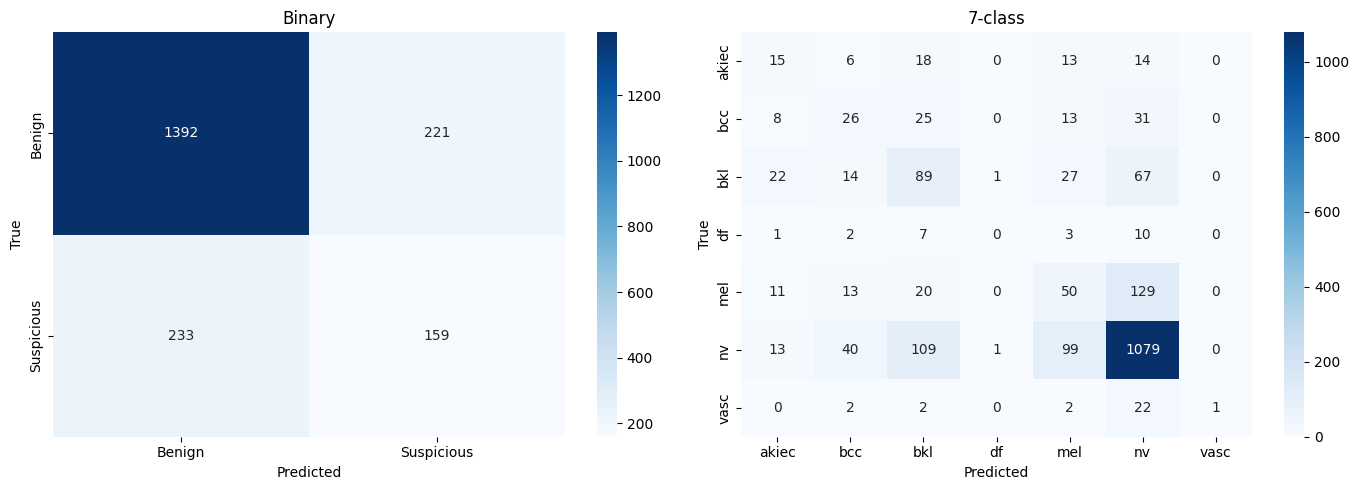

In [8]:
pb, pm = preds["SVM (RBF)"]
box("BINARY CLASSIFICATION REPORT (RBF-SVM)", classification_report(yb_te, pb, target_names=["Benign (0)", "Suspicious (1)"], digits=4) +
    "\nConfusion matrix [rows=true, cols=pred]:\n" + str(confusion_matrix(yb_te, pb)))
box("7-CLASS CLASSIFICATION REPORT (RBF-SVM)", classification_report(ym_te, pm, target_names=CLASSES, digits=4, zero_division=0))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(yb_te, pb), annot=True, fmt="d", cmap="Blues", ax=ax[0], xticklabels=["Benign", "Suspicious"], yticklabels=["Benign", "Suspicious"]); ax[0].set_title("Binary")
sns.heatmap(confusion_matrix(ym_te, pm), annot=True, fmt="d", cmap="Blues", ax=ax[1], xticklabels=CLASSES, yticklabels=CLASSES); ax[1].set_title("7-class")
for a in ax: a.set_xlabel("Predicted"); a.set_ylabel("True")
plt.tight_layout(); plt.show()

## 7. Spatial-filter study (from the paper) applied before HOG
Same five filters as the paper, but here they feed HOG + RBF-SVM instead of a CNN.

In [9]:
rows = []
for f in FILTERS:
    t0 = time.time(); a = [preprocess(i, f) for i in gray_tr]; b = [preprocess(i, f) for i in gray_te]
    Xa, Xb = extract(a, BEST_C, BEST_O), extract(b, BEST_C, BEST_O); t_feat = (time.time() - t0) / (len(a) + len(b)) * 1000
    t0 = time.time(); sb = RBFSVM().fit(Xa, yb_tr); sm = RBFSVM().fit(Xa, ym_tr); t_fit = time.time() - t0
    mb, mm = bmet(yb_te, sb.predict(Xb)), mmet(ym_te, sm.predict(Xb))
    rows.append({"Filter": f, "Bin_Acc": mb["Accuracy"], "Bin_F1": mb["F1"], "Multi_Acc": mm["Accuracy"], "Multi_F1": mm["F1"],
                 "Feat_ms/img": t_feat, "Train_s": t_fit})
filt = pd.DataFrame(rows)
for col in ["Bin_Acc", "Bin_F1", "Multi_Acc", "Multi_F1"]: filt["d_" + col] = filt[col] - filt.loc[0, col]
filt.to_csv("results/filter_study.csv", index=False)
box("SPATIAL FILTER STUDY (HOG + RBF-SVM, test split, change vs. no filter)", filt.round(4).to_string(index=False))

+====================================================================================================================+
|                       SPATIAL FILTER STUDY (HOG + RBF-SVM, test split, change vs. no filter)                       |
+--------------------------------------------------------------------------------------------------------------------+
|   Filter  Bin_Acc  Bin_F1  Multi_Acc  Multi_F1  Feat_ms/img  Train_s  d_Bin_Acc  d_Bin_F1  d_Multi_Acc  d_Multi_F1 |
|     none   0.7736  0.4119     0.6284    0.2767       0.7627   7.9333     0.0000    0.0000       0.0000      0.0000 |
|  average   0.7930  0.4244     0.6404    0.2812       0.8102   7.6239     0.0195    0.0125       0.0120      0.0045 |
| gaussian   0.7796  0.3912     0.6329    0.2696       0.9318   6.3276     0.0060   -0.0207       0.0045     -0.0071 |
|   median   0.7895  0.4073     0.6304    0.2808       1.0217   6.3847     0.0160   -0.0046       0.0020      0.0041 |
|  sharpen   0.7601  0.3119     0.5990    0.2286

## 8. Robustness analysis (brightness, noise, blur, rotation)

+=========================================================================================================+
|                         ROBUSTNESS RESULTS (RBF-SVM, change vs. clean baseline)                         |
+---------------------------------------------------------------------------------------------------------+
|           Condition  Bin_Acc  Bin_F1  Multi_Acc  Multi_F1  d_Bin_Acc  d_Bin_F1  d_Multi_Acc  d_Multi_F1 |
|    Clean (baseline)   0.7736  0.4119     0.6284    0.2767     0.0000    0.0000       0.0000      0.0000 |
|      Brightness +40   0.7701  0.3862     0.6319    0.2739    -0.0035   -0.0258       0.0035     -0.0028 |
|      Brightness -40   0.7726  0.4139     0.6254    0.2641    -0.0010    0.0020      -0.0030     -0.0126 |
| Gaussian noise s=10   0.2419  0.3250     0.0793    0.0545    -0.5317   -0.0869      -0.5491     -0.2222 |
| Gaussian noise s=25   0.1985  0.3268     0.0618    0.0389    -0.5751   -0.0851      -0.5666     -0.2378 |
|            Blur k=3   0.79

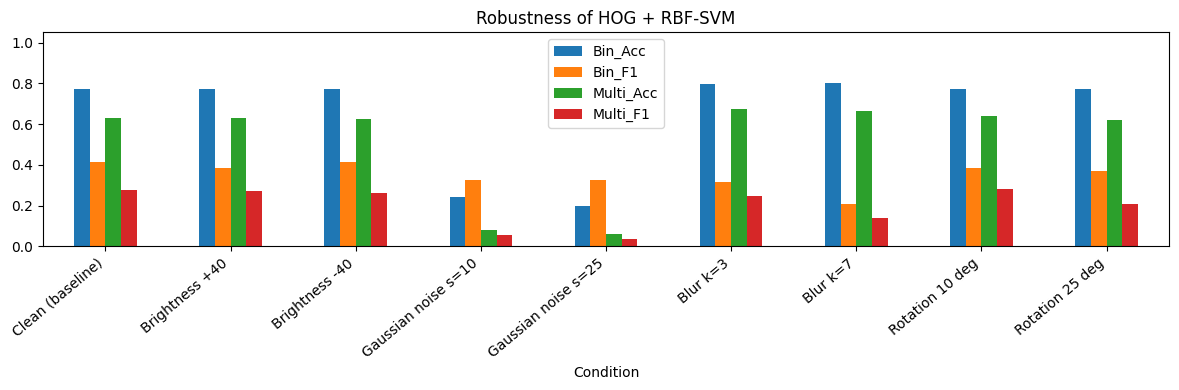

In [10]:
svm_bin = RBFSVM(probability=True).fit(Xtr, yb_tr)
svm_mc  = RBFSVM(probability=True).fit(Xtr, ym_tr)

def brightness(img, beta): return np.clip(img.astype(np.int16) + beta, 0, 255).astype(np.uint8)
def gnoise(img, sigma):
    rng = np.random.default_rng(SEED); return np.clip(img + rng.normal(0, sigma, img.shape), 0, 255).astype(np.uint8)
def blur(img, k): return cv2.GaussianBlur(img, (k, k), 0)
def rotate(img, deg):
    h, w = img.shape; M = cv2.getRotationMatrix2D((w / 2, h / 2), deg, 1.0)
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)

conditions = [("Clean (baseline)", lambda x: x),
              ("Brightness +40", lambda x: brightness(x, 40)), ("Brightness -40", lambda x: brightness(x, -40)),
              ("Gaussian noise s=10", lambda x: gnoise(x, 10)), ("Gaussian noise s=25", lambda x: gnoise(x, 25)),
              ("Blur k=3", lambda x: blur(x, 3)), ("Blur k=7", lambda x: blur(x, 7)),
              ("Rotation 10 deg", lambda x: rotate(x, 10)), ("Rotation 25 deg", lambda x: rotate(x, 25))]
rob = []
for name, fn in conditions:
    Xp = extract([preprocess(fn(i)) for i in gray_te], BEST_C, BEST_O)
    b, m = bmet(yb_te, svm_bin.predict(Xp)), mmet(ym_te, svm_mc.predict(Xp))
    rob.append({"Condition": name, "Bin_Acc": b["Accuracy"], "Bin_F1": b["F1"], "Multi_Acc": m["Accuracy"], "Multi_F1": m["F1"]})
rob = pd.DataFrame(rob)
for col in ["Bin_Acc", "Bin_F1", "Multi_Acc", "Multi_F1"]: rob["d_" + col] = rob[col] - rob.loc[0, col]
rob.to_csv("results/robustness.csv", index=False)
box("ROBUSTNESS RESULTS (RBF-SVM, change vs. clean baseline)", rob.round(4).to_string(index=False) +
    "\n\nd_* columns = change relative to the clean baseline (negative = degradation)")
ax = rob.set_index("Condition")[["Bin_Acc", "Bin_F1", "Multi_Acc", "Multi_F1"]].plot.bar(figsize=(12, 4))
ax.set_ylim(0, 1.05); ax.set_title("Robustness of HOG + RBF-SVM"); plt.xticks(rotation=40, ha="right"); plt.tight_layout(); plt.show()

## 9. Screening decision module

Test image #879 | true class: nv (benign)
+============================================================================+
|                        SKIN LESION SCREENING RESULT                        |
+----------------------------------------------------------------------------+
| Prediction: BENIGN                                                         |
| Confidence: 94.9%                                                          |
| Action: ROUTINE MONITORING                                                 |
| (P(suspicious) = 5.1% | most likely type: nv - melanocytic nevus)          |
| Educational prototype - not a medical diagnosis.                           |
+============================================================================+

Test image #178 | true class: bkl (benign)
+============================================================================+
|                        SKIN LESION SCREENING RESULT                        |
+--------------------------------------------

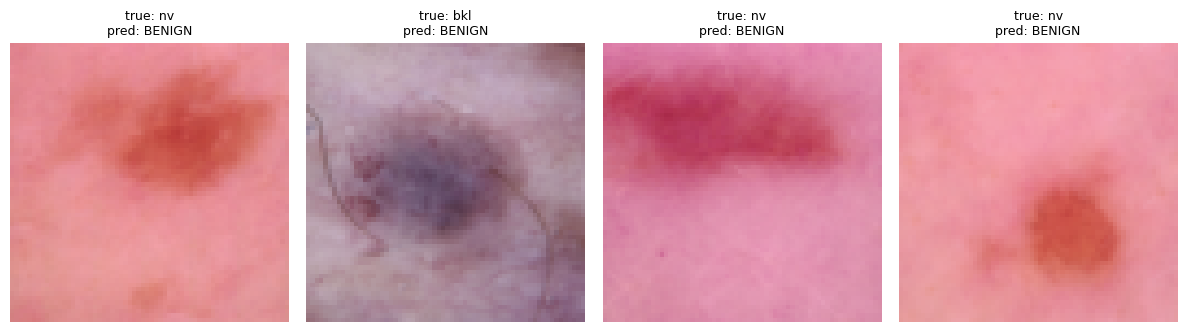

In [11]:
def inspect_lesion(img_or_path, verbose=True):
    """Accepts a file path or an RGB/BGR/gray numpy image. Prints a screening report."""
    img = cv2.imread(img_or_path) if isinstance(img_or_path, str) else img_or_path
    gray = img if img.ndim == 2 else cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)   # pass RGB arrays (cv2.imread paths are BGR; fine for screening)
    x = hog_feat(preprocess(gray), BEST_C, BEST_O).reshape(1, -1)
    p_sus = svm_bin.predict_proba(x)[0][list(svm_bin.classes_).index(1)]
    label = int(p_sus >= REFER_THRESHOLD)
    conf = (p_sus if label == 1 else 1 - p_sus) * 100
    pm = svm_mc.predict_proba(x)[0]; ltype = CLASSES[int(svm_mc.classes_[np.argmax(pm)])]
    out = dict(prediction="SUSPICIOUS" if label else "BENIGN", confidence=conf, p_suspicious=p_sus * 100, lesion_type=ltype,
               action="REFER FOR CLINICAL REVIEW" if label else "ROUTINE MONITORING")
    if verbose:
        box("SKIN LESION SCREENING RESULT",
            f"Prediction: {out['prediction']}\nConfidence: {conf:.1f}%\nAction: {out['action']}\n"
            f"(P(suspicious) = {p_sus*100:.1f}% | most likely type: {ltype} - {FULL_NAMES[ltype]})\n"
            f"Educational prototype - not a medical diagnosis.")
    return out

rng = np.random.default_rng(SEED); idx = rng.choice(len(ym_te), 4, replace=False)
fig, ax = plt.subplots(1, 4, figsize=(12, 3.2))
for a, i in zip(ax, idx):
    print(f"Test image #{i} | true class: {CLASSES[ym_te[i]]} ({'suspicious' if yb_te[i] else 'benign'})")
    r = inspect_lesion(rgb_te[i]); a.imshow(rgb_te[i]); a.axis("off")
    a.set_title(f"true: {CLASSES[ym_te[i]]}\npred: {r['prediction']}", fontsize=9)
plt.tight_layout(); plt.show()

## 10. Final summary

In [12]:
bc = cmp_df.set_index("Classifier"); fw = filt.sort_values("d_Bin_F1").iloc[-1]; rw = rob.iloc[1:].sort_values("d_Bin_F1").iloc[0]
box("FINAL SUMMARY",
    f"Best HOG setting        : cell {BEST_C}x{BEST_C}, {BEST_O} orientations (dim {Xtr.shape[1]})\n"
    f"SVM binary  Acc / F1    : {bc.loc['SVM (RBF)','Bin_Acc']:.4f} / {bc.loc['SVM (RBF)','Bin_F1']:.4f} (recall {bc.loc['SVM (RBF)','Bin_Rec']:.4f})\n"
    f"SVM 7-class Acc / F1    : {bc.loc['SVM (RBF)','Multi_Acc']:.4f} / {bc.loc['SVM (RBF)','Multi_F1']:.4f}\n"
    f"RF  binary  Acc / F1    : {bc.loc['Random Forest','Bin_Acc']:.4f} / {bc.loc['Random Forest','Bin_F1']:.4f}\n"
    f"RF  7-class Acc / F1    : {bc.loc['Random Forest','Multi_Acc']:.4f} / {bc.loc['Random Forest','Multi_F1']:.4f}\n"
    f"Best spatial filter     : {fw.Filter} (binary F1 change {fw.d_Bin_F1:+.4f} vs. none)\n"
    f"Worst robustness drop   : {rw.Condition} (binary F1 {rw.d_Bin_F1:+.4f})\n"
    f"Saved tables            : results/*.csv")

+============================================================================+
|                               FINAL SUMMARY                                |
+----------------------------------------------------------------------------+
| Best HOG setting        : cell 16x16, 6 orientations (dim 216)             |
| SVM binary  Acc / F1    : 0.7736 / 0.4119 (recall 0.4056)                  |
| SVM 7-class Acc / F1    : 0.6284 / 0.2767                                  |
| RF  binary  Acc / F1    : 0.8000 / 0.1148                                  |
| RF  7-class Acc / F1    : 0.6743 / 0.1325                                  |
| Best spatial filter     : average (binary F1 change +0.0125 vs. none)      |
| Worst robustness drop   : Blur k=7 (binary F1 -0.2039)                     |
| Saved tables            : results/*.csv                                    |
+============================================================================+

